<a href="https://colab.research.google.com/github/yuchaotaigu/On-Line-Policy-Iteration/blob/main/multidimensional-assignment/On_line_PI_MDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# On-Line Policy Iteration for the Multidimensional Assignment Problem

Implements the algorithm from:
  "On-Line Policy Iteration for Finite-Horizon Deterministic Optimal Control
   with A Fixed Initial State" (Li, Chen, Li, Fan, Bertsekas, 2026)

Copyright (c) 2026 Yuchao Li

The multidimensional assignment problem (Section 4.1):
  - $N$ layers $(N_0, ..., N_{N})$, each with $m$ nodes.
  - A grouping is a set of N nodes, one per layer.  Its cost depends on the entire tuple $(j_0, j_1, ..., j_{N})$.
  - An $N$-dimensional assignment partitions all m*N nodes into $m$ disjoint groupings.  Its cost is the sum of grouping costs.
  - Goal: find the minimum-cost assignment.

Formulation as an $N$-stage optimal control problem:
  - Control $u_k$ is a permutation mapping layer-$k$ nodes to layer-$(k+1)$ nodes.
  - State $x_k = (u_0, ..., u_{k-1})$ records the arcs chosen so far.
  - Stage costs $g_k$ = 0 for $k < N$;  terminal cost $g_N(x_N)$ is the assignment cost determined by $(u_0, ..., u_{N-1})$.
  - A policy $\pi^\ell$ is represented by the stored trajectory; the generator $G$ replays it (consistent by construction).

Key insight for the minimization at stage k:
  Given the prefix $(u_0^{\ell+1}, ..., u_{k-1}^{\ell+1})$ and the suffix from policy $\pi^\ell$ as $(u_{k+1}^\ell, ..., u_{N-2}^\ell)$, the only free variable is the
  permutation $u_k$.  The total cost decomposes as a sum over $m$ groupings, and each grouping's contribution depends only on which node it visits at layer $k+1$ (the rest of the path is fixed).  So choosing $u_k$ amounts to
  solving a bipartite matching (linear assignment) problem, where the weight of assigning node a at layer $k$ to node $b$ at layer $k+1$ equals the grouping cost of the path that passes through a at layer $k$ and $b$ at layer $k+1$.

In [ ]:
!apt-get -qq install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Extracting templates from packages: 100%
Preconfiguring packages ...
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package fonts-lato.
Preparing to unpack .../01-fonts-lato_2.0-2.1_all.deb ...
Unpacking fonts-lato (2.0-2.1) ...
Selecting previously unselected package poppler-data.
Preparing to unpack .../02-poppler-data_0.4.11-1_all.deb ...
Unpacking poppler-data (0.4.11-1) ...
Selecting previously unselected package tex-common.
Preparing to unpack .../03-tex-common_6.17_all.deb ...
Unpacking tex-common (6.17) ...
Selecting previously unselected package libkpathsea6:amd64.
Preparing to unpack .../04-libkpathsea6_2021.20210626.59705-1ubuntu0.3_amd64.deb ...
Unpacking libkpathsea6:amd64 (2021.20210626.59705-1ubuntu0.3) ...
Selecti

In [ ]:
import itertools
import math
import time

import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------------------------
# Problem definition
# ---------------------------------------------------------------------------

def random_grouping_costs(N: int, m: int, seed: int = 0) -> np.ndarray:
    """
    Generate random grouping costs.

    There are N+1 layers (N_0, ..., N_N).  Each grouping is a tuple
    (j_0, j_1, ..., j_N) with j_k in {0, ..., m-1} specifying which node
    the grouping visits at each layer.  The cost of a grouping is a general
    function of this entire tuple — there is no additive or separable
    structure across layers.

    We store costs in an array of shape (m, m, ..., m) with N+1 dimensions:
        costs[j_0, j_1, ..., j_N] = cost of grouping (j_0, j_1, ..., j_N).

    The costs are drawn i.i.d. from Uniform(0, 100).

    Note: the array has m^{N+1} entries, so this is feasible only for
    moderate N and m.

    Parameters
    ----------
    N : int – number of stages (there are N+1 layers)
    m : int – number of nodes per layer
    seed : int – random seed for reproducibility

    Returns
    -------
    costs : np.ndarray of shape (m,)*(N+1)
    """
    rng = np.random.RandomState(seed)
    return rng.uniform(0, 100, size=(m,) * (N + 1))


# ---------------------------------------------------------------------------
# Trajectory / policy representation
# ---------------------------------------------------------------------------

class Policy:
    """
    A policy for the assignment problem is a stored trajectory of N
    permutations: (u_0, u_1, ..., u_{N-1}).

    The generator G takes a feasible trajectory and records it as a policy.
    This is consistent (Eq. 14): along the trajectory, mu_k(x_k) = u_k.
    """

    def __init__(self, perms: list[np.ndarray]):
        self.perms = [p.copy() for p in perms]

    @property
    def num_stages(self):
        """Number of control stages = N."""
        return len(self.perms)

    def copy(self):
        return Policy(self.perms)


# ---------------------------------------------------------------------------
# Cost evaluation
# ---------------------------------------------------------------------------

def assignment_cost(costs: np.ndarray, perms: list[np.ndarray]) -> float:
    """
    Compute total assignment cost given a sequence of N permutations.

    Grouping i traverses N+1 layers:
      layer 0: node i
      layer 1: node perms[0][i]
      layer 2: node perms[1][ perms[0][i] ]
      ...
      layer N: node perms[N-1][ ... [ perms[0][i] ] ... ]

    Parameters
    ----------
    costs : np.ndarray of shape (m,)*(N+1) – grouping cost table
    perms : list of N permutations, each np.ndarray of length m

    Returns
    -------
    total_cost : float – sum of grouping costs over all m groupings
    """
    num_layers = costs.ndim   # N+1
    m = costs.shape[0]
    total = 0.0
    for i in range(m):
        idx = [0] * num_layers
        idx[0] = i
        node = i
        for k in range(num_layers - 1):  # k = 0, ..., N-1
            node = perms[k][node]
            idx[k + 1] = node
        total += costs[tuple(idx)]
    return total

In [ ]:
# ---------------------------------------------------------------------------
# On-Line PI iteration (Eqs. 9-13)
# ---------------------------------------------------------------------------

def online_pi_iteration(
    costs: np.ndarray,
    policy: Policy,
) -> Policy:
    """
    One iteration of on-line PI (Eqs. 9-13 of the paper).

    At stage k (k = 0, ..., N-1), we choose u_k^{l+1} by solving a
    bipartite matching problem:

      - The prefix (u_0^{l+1}, ..., u_{k-1}^{l+1}) is already fixed.
      - The suffix (u_{k+1}^l, ..., u_{N-1}^l) comes from the current policy.
      - For each grouping i, the node at layer k is determined by the prefix.
        The only free choice is which node b at layer k+1 it connects to.
        Once b is chosen, the suffix determines the rest of the path, giving
        a fully determined grouping cost.
      - The total cost decomposes as a sum over m groupings, so choosing
        the permutation u_k to minimize total cost is a bipartite matching
        (linear assignment) problem.

    Parameters
    ----------
    costs : np.ndarray of shape (m,)*(N+1) – grouping cost table
    policy : current policy pi^l (N permutations)

    Returns
    -------
    new_policy : Policy – improved policy pi^{l+1}
    """
    num_stages = policy.num_stages  # N
    m = costs.shape[0]

    new_perms: list[np.ndarray] = []

    for k in range(num_stages):
        # For each grouping i, compute the node it reaches at layer k
        # using the NEW prefix (stages 0..k-1).
        node_at_k = np.zeros(m, dtype=int)
        for i in range(m):
            node = i
            for s in range(k):
                node = new_perms[s][node]
            node_at_k[i] = node

        # For each candidate node b at layer k+1, compute the suffix path
        # (layers k+1, k+2, ..., N) under the current policy.
        suffix_paths = {}
        for b in range(m):
            path = [b]
            node = b
            for s in range(k + 1, num_stages):
                node = policy.perms[s][node]
                path.append(node)
            suffix_paths[b] = path

        # For each grouping i, compute the prefix path (layers 0, ..., k).
        prefix_paths = []
        for i in range(m):
            prefix = [i]
            node = i
            for s in range(k):
                node = new_perms[s][node]
                prefix.append(node)
            prefix_paths.append(prefix)

        # Build the m x m cost matrix for the bipartite matching.
        # C_grouping[i, b] = cost of grouping i if it goes to node b
        # at layer k+1.
        C_grouping = np.zeros((m, m))
        for i in range(m):
            for b in range(m):
                full_path = prefix_paths[i] + suffix_paths[b]
                C_grouping[i, b] = costs[tuple(full_path)]

        # Reindex as a matching on (node_at_layer_k) -> (node_at_layer_k+1).
        # Since node_at_k is a permutation, inv[a] = grouping i such that
        # node_at_k[i] = a.
        inv_node_at_k = np.zeros(m, dtype=int)
        for i in range(m):
            inv_node_at_k[node_at_k[i]] = i

        C_matching = np.zeros((m, m))
        for a in range(m):
            i = inv_node_at_k[a]
            C_matching[a, :] = C_grouping[i, :]

        # Solve the linear assignment problem.
        row_ind, col_ind = linear_sum_assignment(C_matching)

        new_perm = np.zeros(m, dtype=int)
        for a, b in zip(row_ind, col_ind):
            new_perm[a] = b

        new_perms.append(new_perm)

    return Policy(new_perms)


# ---------------------------------------------------------------------------
# Brute-force optimal (small instances only)
# ---------------------------------------------------------------------------

def brute_force_optimal(costs: np.ndarray) -> tuple[float, list[np.ndarray]]:
    """Exhaustive search over all (m!)^N assignments."""
    num_stages = costs.ndim - 1  # N
    m = costs.shape[0]
    all_perms = [np.array(p, dtype=int) for p in itertools.permutations(range(m))]

    best_cost = math.inf
    best_combo = None
    for combo in itertools.product(all_perms, repeat=num_stages):
        c = assignment_cost(costs, list(combo))
        if c < best_cost:
            best_cost = c
            best_combo = list(combo)
    return best_cost, best_combo

In [ ]:
# ---------------------------------------------------------------------------
# Run on-line PI and return cost history
# ---------------------------------------------------------------------------

def run_online_pi(
    N: int,
    m: int,
    seed: int = 0,
    init_seed: int = None,
    max_iters: int = 50,
    verbose: bool = True,
) -> list[float]:
    """
    Run on-line PI and return cost history.

    Parameters
    ----------
    N : number of stages (N+1 layers)
    m : nodes per layer
    seed : random seed for cost generation
    init_seed : random seed for initial policy (default: seed + 10000)
    max_iters : maximum number of PI iterations
    verbose : print iteration details

    Returns
    -------
    cost_history : list of costs J_{pi^l}(x_0) for l = 0, 1, ...
    """
    costs = random_grouping_costs(N, m, seed=seed)

    if init_seed is None:
        init_seed = seed + 10000

    if verbose:
        print(f"{'=' * 65}")
        print(f"N={N} stages ({N + 1} layers), m={m} nodes/layer, seed={seed}")
        print(f"Grouping cost array: shape {costs.shape}, "
              f"{costs.size} entries (i.i.d. Uniform(0, 100))")
        print(f"{'=' * 65}")

    # Random initial policy: N permutations
    # Use numpy RNG (seeded deterministically) for cross-platform reproducibility
    rng = np.random.RandomState(init_seed)
    init_perms = [rng.permutation(m).astype(int) for _ in range(N)]

    policy = Policy(init_perms)
    init_cost = assignment_cost(costs, policy.perms)
    cost_history = [init_cost]

    if verbose:
        print(f"  Iter  0 (initial):  cost = {init_cost:.4f}")

    for it in range(1, max_iters + 1):
        t0 = time.time()
        new_policy = online_pi_iteration(costs, policy)
        elapsed = time.time() - t0

        new_cost = assignment_cost(costs, new_policy.perms)
        cost_history.append(new_cost)

        if verbose:
            print(f"  Iter {it:>2}:           cost = {new_cost:.4f}  "
                  f"(Δ = {new_cost - cost_history[-2]:+.4f}, "
                  f"time = {elapsed:.3f}s)")

        # Verify monotone decrease (Proposition 3.1)
        assert new_cost <= cost_history[-2] + 1e-9, \
            f"Cost increased! {cost_history[-2]:.6f} -> {new_cost:.6f}"

        if abs(new_cost - assignment_cost(costs, policy.perms)) < 1e-12:
            if verbose:
                print(f"  Converged at iteration {it}.")
            policy = new_policy
            break
        policy = new_policy

    if verbose:
        print()
    return cost_history


# ---------------------------------------------------------------------------
# Plot optimality gap figure
# ---------------------------------------------------------------------------

def plot_optimality_gap(save_path: str = None):
    """
    Run on-line PI on selected instances, compute J* via brute force,
    and plot the optimality gap (J_{pi^l} - J*) / J* vs iteration.

    The instances are chosen to be small enough for brute-force computation
    of J* while exhibiting multi-iteration improvement (4-6 improving steps).

    Parameters
    ----------
    save_path : str or None
        If provided, save the figure to this path. Otherwise, display it.
    """
    # Selected instances: (N, m, seed, init_seed, label, color, linestyle, marker)
    # Chosen to exhibit varying convergence speeds (1 to 6 improving iterations).
    experiments = [
        (7, 3,    3, 10003, r"$N=7,\ m=3$", "#D4537E", "--", "p"),   # 1 iter
        (7, 3,   64, 10064, r"$N=7,\ m=3$", "#534AB7", "-",  "o"),   # 4 iters
        (6, 3,    7, 10007, r"$N=6,\ m=3$", "#1D9E75", "--", "s"),   # 5 iters
        (4, 4,   74, 10074, r"$N=4,\ m=4$", "#3266ad", "-.", "v"),   # 5 iters
        (5, 3,  746, 10746, r"$N=5,\ m=3$", "#D85A30", ":",  "D"),   # 6 iters
        (4, 4,  281, 30281, r"$N=4,\ m=4$", "#85B7EB", "-",  "^"),   # 6 iters
    ]

    # Use Times New Roman for text, Computer Modern for math symbols.
    # Full LaTeX rendering requires latex + dvipng. On Colab, install via:
    #   !apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super
    import shutil
    use_latex = (shutil.which("latex") is not None
                 and shutil.which("dvipng") is not None)
    if use_latex:
        try:
            plt.rcParams.update({"text.usetex": True})
            # Quick test to catch missing LaTeX packages early
            fig_test, ax_test = plt.subplots()
            ax_test.set_xlabel(r"$x$")
            fig_test.savefig("/dev/null", format="png")
            plt.close(fig_test)
        except Exception:
            use_latex = False
            plt.rcParams.update({"text.usetex": False})

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "cm",
    })

    fig, ax = plt.subplots(figsize=(7, 4.5))

    for N, m, seed, init_seed, label, color, ls, marker in experiments:
        print(f"Running N={N}, m={m}, seed={seed}, init_seed={init_seed} ...")

        # Run on-line PI
        t0 = time.time()
        cost_history = run_online_pi(N, m, seed=seed, init_seed=init_seed,
                                     max_iters=30, verbose=False)
        pi_time = time.time() - t0

        # Compute brute-force optimal
        costs = random_grouping_costs(N, m, seed=seed)
        t0 = time.time()
        opt_cost, _ = brute_force_optimal(costs)
        bf_time = time.time() - t0

        # Compute optimality gap
        gaps = [(c - opt_cost) / opt_cost for c in cost_history]
        iters = list(range(len(gaps)))

        print(f"  J* = {opt_cost:.4f}, "
              f"iters = {len(gaps) - 1}, "
              f"final gap = {gaps[-1]:.4f}, "
              f"on-line PI time = {pi_time:.3f}s, "
              f"brute-force time = {bf_time:.3f}s")

        ax.plot(iters, gaps, color=color, linestyle=ls, linewidth=1.5,
                marker=marker, markersize=5, label=label)

    ax.set_xlabel(r"Iteration $\ell$", fontsize=13)
    ax.set_ylabel(r"$(J_{\pi^\ell} - J^*) \,/\, J^*$ (\%)", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\nFigure saved to {save_path}")
    else:
        plt.show()

    return fig, ax




In [ ]:
# ---------------------------------------------------------------------------
# Plot cost reduction figure for large instances (J* unavailable)
# ---------------------------------------------------------------------------

def plot_cost_reduction(save_path: str = None):
    """
    Run on-line PI on large instances where brute-force J* is infeasible,
    and plot J_{pi^l} / J_{pi^0} (in percent) vs iteration.

    Parameters
    ----------
    save_path : str or None
        If provided, save the figure to this path.  Otherwise, display it.
    """
    # Selected large instances: (N, m, seed, init_seed, label, color, linestyle, marker)
    # These are too large for brute-force (e.g., (10,4) has 4^11 ≈ 4M cost entries,
    # (6,6) has 6^7 ≈ 280K, and brute force requires (m!)^N evaluations).
    experiments = [
        (10, 4,  36, 20036, r"$N=10,\ m=4$", "#D4537E", "--", "p"),   # 6 iters
        (6,  6, 128, 20128, r"$N=6,\ m=6$",  "#534AB7", "-",  "o"),   # 6 iters
        (8,  5, 172, 20172, r"$N=8,\ m=5$",  "#1D9E75", "--", "s"),   # 5 iters
        (12, 3, 152, 30152, r"$N=12,\ m=3$", "#3266ad", "-.", "v"),   # 5 iters
        (8,  4, 139, 30139, r"$N=8,\ m=4$",  "#D85A30", ":",  "D"),   # 6 iters
        (10, 3, 128, 10128, r"$N=10,\ m=3$", "#85B7EB", "-",  "^"),   # 6 iters
    ]

    import shutil
    use_latex = (shutil.which("latex") is not None
                 and shutil.which("dvipng") is not None)
    if use_latex:
        try:
            plt.rcParams.update({"text.usetex": True})
            fig_test, ax_test = plt.subplots()
            ax_test.set_xlabel(r"$x$")
            fig_test.savefig("/dev/null", format="png")
            plt.close(fig_test)
        except Exception:
            use_latex = False
            plt.rcParams.update({"text.usetex": False})

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "cm",
    })

    fig, ax = plt.subplots(figsize=(7, 4.5))

    for N, m, seed, init_seed, label, color, ls, marker in experiments:
        print(f"Running N={N}, m={m}, seed={seed}, init_seed={init_seed} ...")

        t0 = time.time()
        cost_history = run_online_pi(N, m, seed=seed, init_seed=init_seed,
                                     max_iters=30, verbose=False)
        elapsed = time.time() - t0

        # Compute J_{pi^l} / J_{pi^0} in percent
        ratios = [(c / cost_history[0]) * 100 for c in cost_history]
        iters = list(range(len(ratios)))

        print(f"  iters = {len(ratios) - 1}, "
              f"final ratio = {ratios[-1]:.2f}%, "
              f"time = {elapsed:.3f}s")

        ax.plot(iters, ratios, color=color, linestyle=ls, linewidth=1.5,
                marker=marker, markersize=5, label=label)

    ax.set_xlabel(r"Iteration $\ell$", fontsize=13)
    ax.set_ylabel(r"$J_{\pi^\ell} \,/\, J_{\pi^0}$ (\%)", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0, top=105)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\nFigure saved to {save_path}")
    else:
        plt.show()

    return fig, ax


Running N=7, m=3, seed=3, init_seed=10003 ...
  J* = 3.8091, iters = 2, final gap = 7.5493, on-line PI time = 0.002s, brute-force time = 1.726s
Running N=7, m=3, seed=64, init_seed=10064 ...
  J* = 1.4814, iters = 4, final gap = 7.4195, on-line PI time = 0.002s, brute-force time = 1.725s
Running N=6, m=3, seed=7, init_seed=10007 ...
  J* = 4.2710, iters = 5, final gap = 3.6697, on-line PI time = 0.002s, brute-force time = 0.253s
Running N=4, m=4, seed=74, init_seed=10074 ...
  J* = 6.3205, iters = 5, final gap = 0.9586, on-line PI time = 0.002s, brute-force time = 1.836s
Running N=5, m=3, seed=746, init_seed=10746 ...
  J* = 9.3304, iters = 6, final gap = 0.1404, on-line PI time = 0.002s, brute-force time = 0.037s
Running N=4, m=4, seed=281, init_seed=30281 ...
  J* = 8.3166, iters = 6, final gap = 0.8180, on-line PI time = 0.002s, brute-force time = 2.983s

Figure saved to optimality_gap.pdf
Running N=10, m=4, seed=36, init_seed=20036 ...
  iters = 6, final ratio = 4.94%, time = 0.063

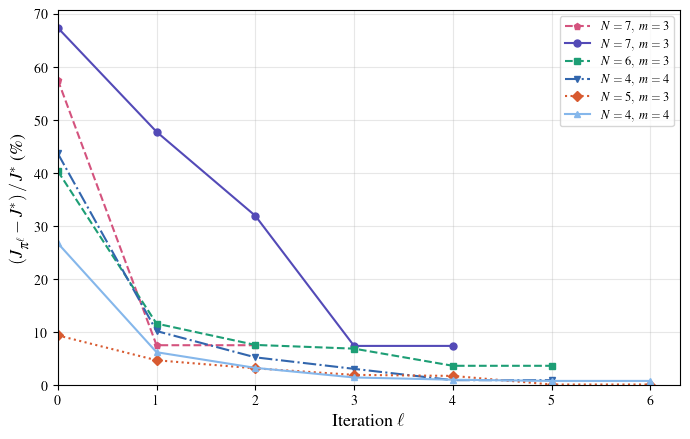

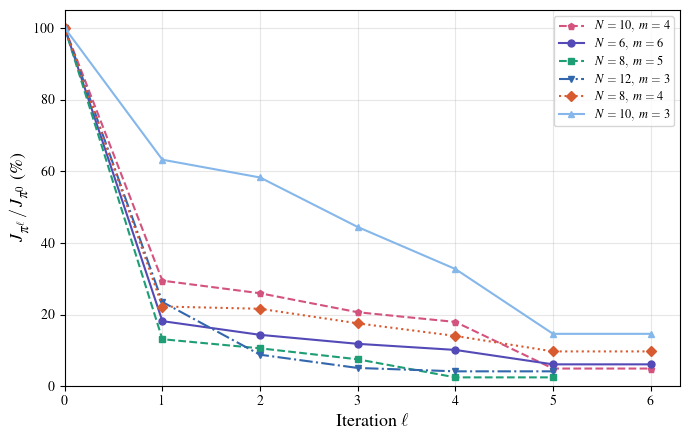

In [ ]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    plot_optimality_gap(save_path="optimality_gap.pdf")
    plot_cost_reduction(save_path="cost_reduction.pdf")
